# SDP Coarray Reconstruction Algorithm Performance Evaluation

This notebook demonstrates the performance evaluation of multiple SDP (Semi-Definite Programming) coarray covariance matrix reconstruction algorithms for DOA estimation.

We will evaluate the following SDP coarray reconstruction algorithms combined with RootMUSIC:
- ANM (Atomic Norm Minimization)
- SPA (Sparse Priors Approach)
- StructCovMLE
- Wasserstein

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import doatools.model as model
import doatools.estimation as estimation
import doatools.performance as perf
import doatools.plotting as plt_tools
from tqdm import tqdm
%matplotlib inline

# 设置全局字体和大小
plt.rcParams.update({

    'font.family': 'Times New Roman',
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18, 
    'legend.fontsize': 18,
    'legend.loc': 'upper right',
    'legend.title_fontsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18
})

## 1. Simulation Parameters Setup

In [2]:
# Basic parameters
wavelength = 1.0
d0 = wavelength / 2
n_sources = 3
source_angles = np.linspace(-np.pi/5, np.pi/6, n_sources)

# Array design - CoPrime Array
# m1, m2 = 3, 4  # Co-prime numbers
# array = model.CoPrimeArray(m1, m2, d0)
array = model.GridBasedArrayDesign(indices=np.array([0, 1, 4, 9, 20, 22])[:, np.newaxis], d0=d0, name='ONRA-da')
print(f'Number of physical elements: {array.size}')
# Source placement
sources = model.FarField1DSourcePlacement(source_angles)
print(f'Source angles (deg): {np.rad2deg(source_angles)}')
# Monte Carlo simulation parameters
n_monte_carlo = 100

Number of physical elements: 6
Source angles (deg): [-36.  -3.  30.]


## 1.1 Problem

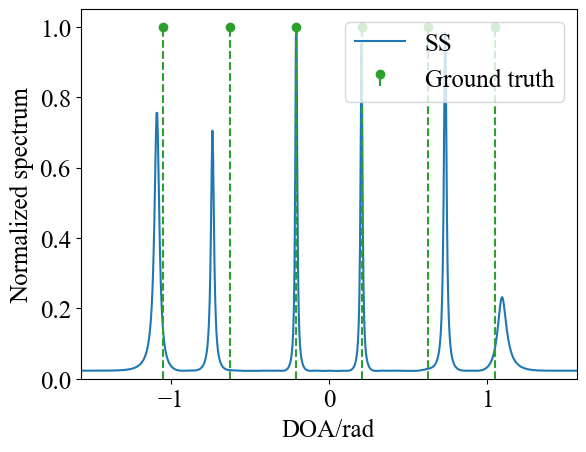

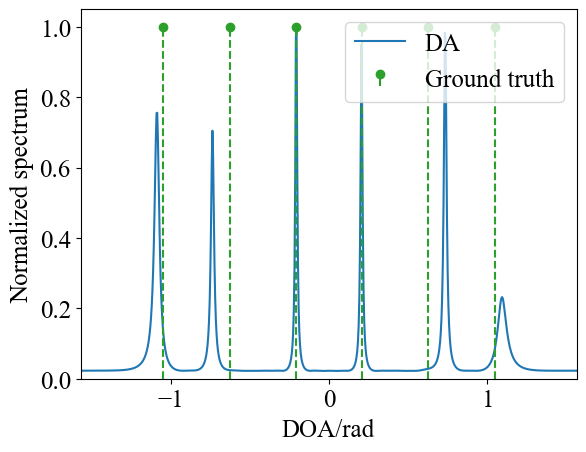

DA: [-62.25 -42.25 -11.75  11.75  42.    62.75];
 SS: [-62.25 -42.25 -11.75  11.75  42.    62.75];
 Truth:[-60. -36. -12.  12.  36.  60.]


In [3]:
sources = model.FarField1DSourcePlacement(
    np.linspace(-np.pi/3, np.pi/3, 6)
)
source_signal = model.ComplexStochasticSignal(sources.size, 1.0)
noise_signal = model.ComplexStochasticSignal(array.size, 1.0)
_, R = model.get_narrowband_snapshots(array, sources, wavelength, source_signal, noise_signal,1024, return_covariance=True)

grid = estimation.FarField1DSearchGrid(size=720)
acm_builder = estimation.CoarrayACMBuilder1D(array)
virtual_ula = acm_builder.get_virtual_ula()
Rss = acm_builder.transform(R, 'ss')
Rda = acm_builder.transform(R, 'da')
music = estimation.MUSIC(virtual_ula, wavelength, grid)
resv_ss, est_ss, sp_ss = music.estimate(Rss, sources.size, return_spectrum=True)
resv_da, est_da, sp_da = music.estimate(Rda, sources.size, return_spectrum=True)
plt_tools.plot_spectrum({'SS': sp_ss}, grid, ground_truth=sources)
plt_tools.plot_spectrum({'DA': sp_da}, grid, ground_truth=sources)
print(f"DA: {np.rad2deg(est_da.locations)};\n SS: {np.rad2deg(est_ss.locations)};\n Truth:{np.rad2deg(sources.locations)}")

 ## 2. Define SDP Estimators

In [4]:
# Define estimators
estimators = {
    'ANM-RootMUSIC': estimation.ANMEstimator(array, wavelength, zeta=0.0),
    'SPA-RootMUSIC': estimation.SPAEstimator(array, wavelength),
    'StructCovMLE-RootMUSIC': estimation.StructCovMLEEstimator(array, wavelength),
    'Wasserstein-RootMUSIC': estimation.WassersteinEstimator(array, wavelength)
}

# Set DOA estimator for all SDP estimators
root_music_estimator = estimation.RootMUSIC1D(wavelength)
for estimator in estimators.values():
    estimator.doa_estimator = root_music_estimator

print(f'Defined estimators: {list(estimators.keys())}')

Defined estimators: ['ANM-RootMUSIC', 'SPA-RootMUSIC', 'StructCovMLE-RootMUSIC', 'Wasserstein-RootMUSIC']


## 3. Performance vs. SNR

In [5]:
# Parameters for SNR test
snr_values = np.linspace(-10, 10, 11)  # SNR values from -10 dB to 20 dB
n_snapshots_snr = 1024  # Number of snapshots for SNR test

print(f'Running SNR performance test with {snr_values} SNR points...')

# Initialize results storage
snr_results = {alg: {'mse': [], 'bias': []} for alg in estimators.keys()}

# Run simulation for each SNR
for snr in snr_values:
    print(f"snr -> {snr}")
    # Run performance evaluation
    result = perf.evaluate_performance(
        array=array,
        sources=sources,
        snr=snr,
        n_snapshots=n_snapshots_snr,
        n_monte_carlo=n_monte_carlo,
        estimators=estimators,
        metrics=['mse', 'bias'],
        verbose=1,
        n_jobs=8,
    )
    
    # Store results
    for alg in estimators.keys():
        snr_results[alg]['mse'].append(result.estimator_results[alg]['mse']) 
        snr_results[alg]['bias'].append(result.estimator_results[alg]['bias']) 

# Convert lists to numpy arrays for easier plotting
for alg in snr_results.keys():
    snr_results[alg]['mse'] = np.array(snr_results[alg]['mse']) 
    snr_results[alg]['bias'] = np.array(snr_results[alg]['bias']) 

print('SNR performance test completed!')

Running SNR performance test with [-10.  -8.  -6.  -4.  -2.   0.   2.   4.   6.   8.  10.] SNR points...
snr -> -10.0


Evaluating estimators: 100%|██████████| 400/400 [02:57<00:00,  2.25it/s]


snr -> -8.0


Evaluating estimators: 100%|██████████| 400/400 [02:56<00:00,  2.27it/s]


snr -> -6.0


...

snr -> 8.0


Evaluating estimators: 100%|██████████| 400/400 [03:01<00:00,  2.21it/s]


snr -> 10.0


Evaluating estimators: 100%|██████████| 400/400 [03:01<00:00,  2.21it/s]

SNR performance test completed!


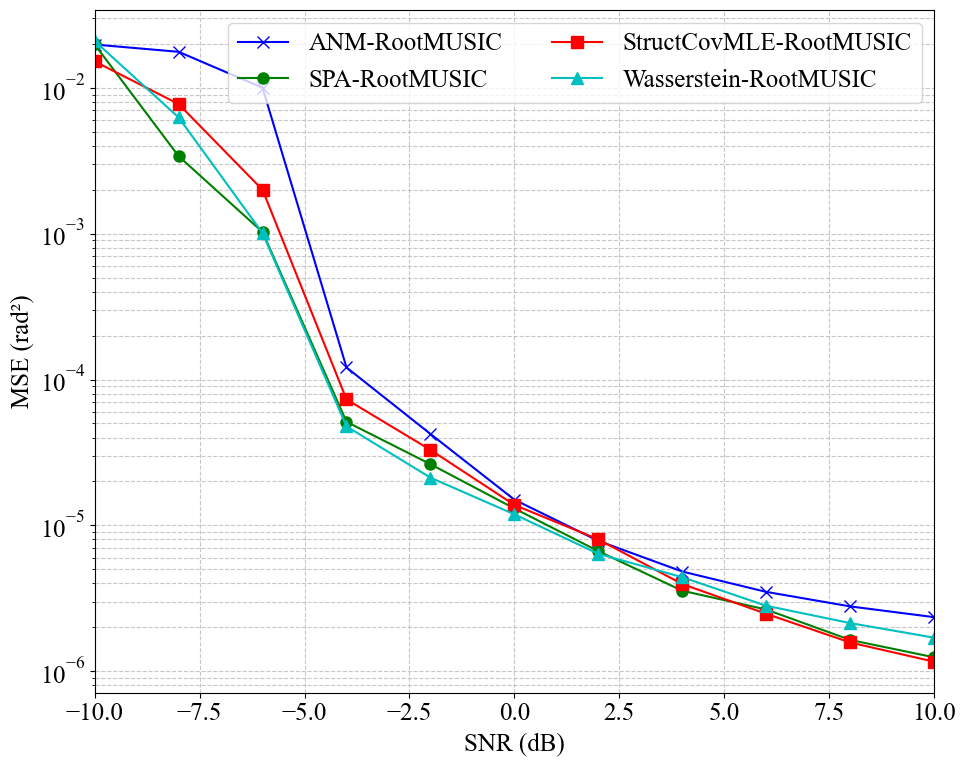

In [6]:
# Plot MSE vs SNR using our plotting tool
fig, ax = plt.subplots(figsize=(10, 8))
plt_tools.plot_metric_vs_parameter(
    parameter_values=snr_values,
    results={alg: snr_results[alg]['mse'] for alg in snr_results.keys()},
    parameter_name='SNR',
    metric_name='MSE',
    parameter_unit='dB',
    metric_unit='rad²',
    show_crb=False,
    ax=ax
    )
plt.tight_layout()
plt.show()

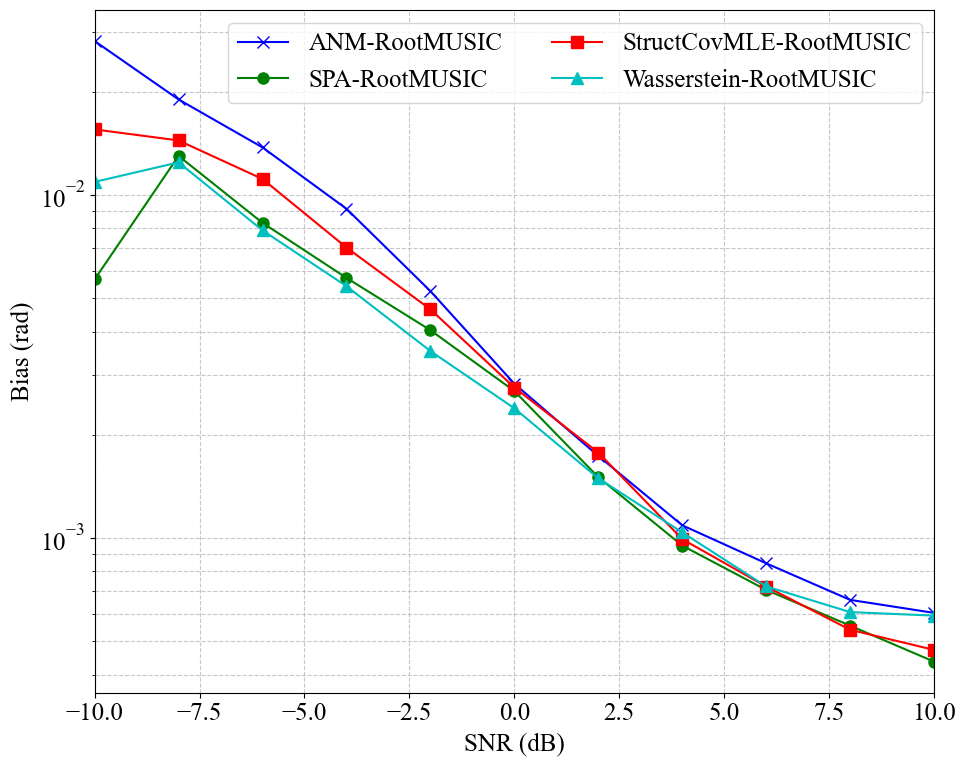

In [7]:
# Plot Bias vs SNR using our plotting tool
fig, ax = plt.subplots(figsize=(10, 8))
plt_tools.plot_metric_vs_parameter(
    parameter_values=snr_values,
    results={alg: snr_results[alg]['bias'] for alg in snr_results.keys()},
    parameter_name='SNR',
    metric_name='Bias',
    parameter_unit='dB',
    metric_unit='rad',
    ax=ax
    )
plt.tight_layout()
plt.show()

## 4. Performance vs. Number of Snapshots

In [5]:
# Parameters for snapshot test
snapshot_values = np.array([50, 100, 200, 500, 1000])  # Number of snapshots
snr_snapshot = 10.0  # SNR in dB for snapshot test

print(f'Running snapshot performance test with {len(snapshot_values)} snapshot points...')

# Initialize results storage
snapshot_results = {alg: {'mse': [], 'bias': []} for alg in estimators.keys()}

# Run simulation for each snapshot count
for n_snap in tqdm(snapshot_values):
    # Run performance evaluation
    result = perf.evaluate_performance(
        array=array,
        sources=sources,
        snr=snr_snapshot,
        n_snapshots=n_snap,
        n_monte_carlo=n_monte_carlo,
        estimators=estimators,
        metrics=['mse', 'bias'],
        n_jobs=6
    )
    
    # Store results
    for alg in estimators.keys():
        snapshot_results[alg]['mse'].append(result.estimator_results[alg]['mse']) 
        snapshot_results[alg]['bias'].append(result.estimator_results[alg]['bias']) 

# Convert lists to numpy arrays for easier plotting
for alg in snapshot_results.keys():
    snapshot_results[alg]['mse'] = np.array(snapshot_results[alg]['mse']) 
    snapshot_results[alg]['bias'] = np.array(snapshot_results[alg]['bias']) 

print('Snapshot performance test completed!')

Running snapshot performance test with 5 snapshot points...


100%|██████████| 5/5 [18:30<00:00, 222.18s/it]

Snapshot performance test completed!


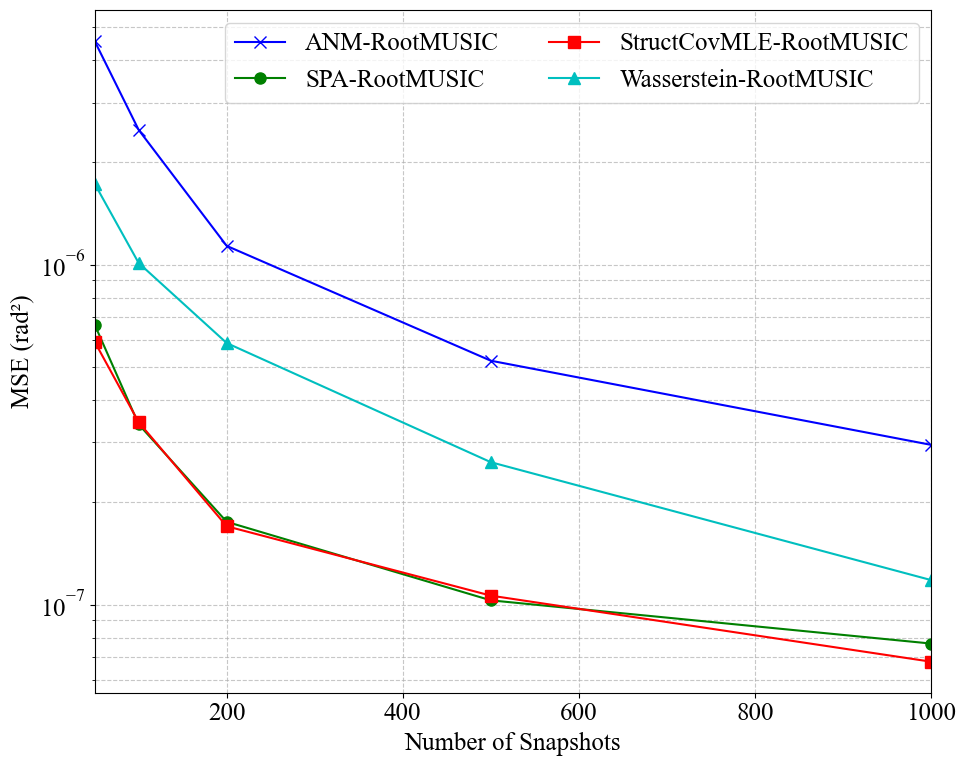

In [6]:
# Plot MSE vs Number of Snapshots using our plotting tool
fig, ax = plt.subplots(figsize=(10, 8))
plt_tools.plot_metric_vs_parameter(
    parameter_values=snapshot_values,
    results={alg: snapshot_results[alg]['mse'] for alg in snapshot_results.keys()},
    parameter_name='Number of Snapshots',
    metric_name='MSE',
    metric_unit='rad²',
    show_crb=False,
    ax=ax
    )
plt.tight_layout()
plt.show()

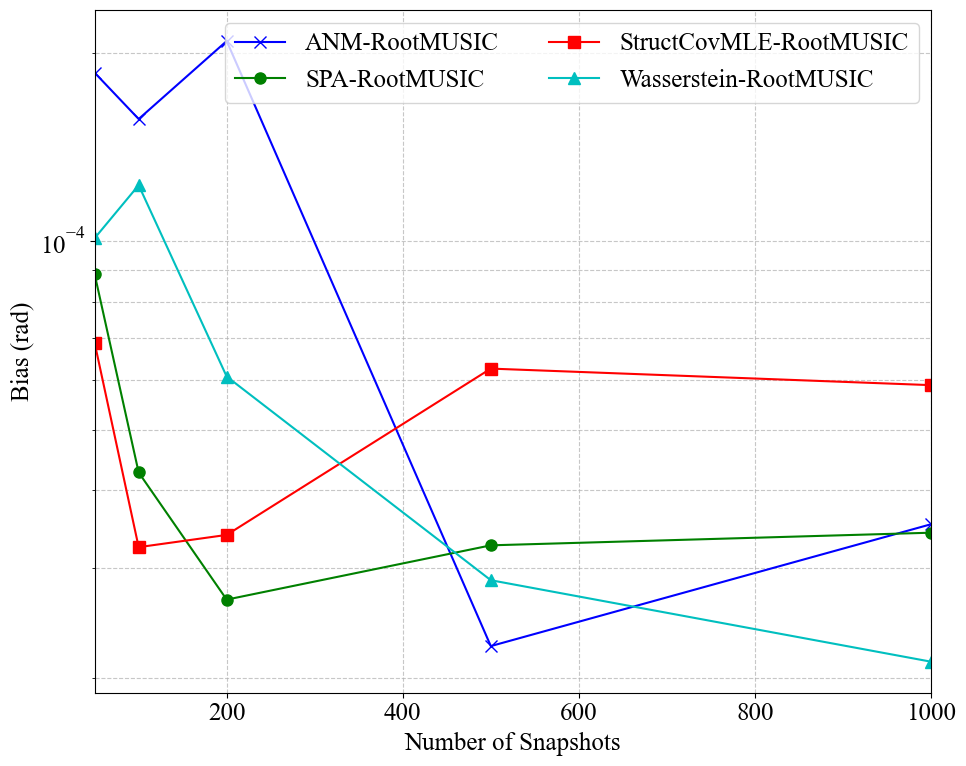

In [7]:
# Plot Bias vs Number of Snapshots using our plotting tool
fig, ax = plt.subplots(figsize=(10, 8))
plt_tools.plot_metric_vs_parameter(
    parameter_values=snapshot_values,
    results={alg: snapshot_results[alg]['bias'] for alg in snapshot_results.keys()},
    parameter_name='Number of Snapshots',
    metric_name='Bias',
    metric_unit='rad',
    ax=ax
    )
plt.tight_layout()
plt.show()

## 5. Performance vs. Number of Sources

In [8]:
# Parameters for source number test
n_sources_values = np.arange(2, 6)  # Number of sources from 2 to 5
snr_source = 10.0  # SNR in dB for source number test
n_snapshots_source = 256  # Number of snapshots for source number test

print(f'Running source number performance test with {len(n_sources_values)} source counts...')

# Initialize results storage
source_results = {alg: {'mse': [], 'bias': []} for alg in estimators.keys()}

# Run simulation for each source count
for n_sources_test in tqdm(n_sources_values):
    # Create sources with current number of sources
    test_source_angles = np.linspace(-np.pi/4, np.pi/3, n_sources_test)
    test_sources = model.FarField1DSourcePlacement(test_source_angles)
    
    # Run performance evaluation
    result = perf.evaluate_performance(
        array=array,
        sources=test_sources,
        snr=snr_source,
        n_snapshots=n_snapshots_source,
        n_monte_carlo=n_monte_carlo,
        estimators=estimators,
        metrics=['mse', 'bias'],
        verbose=1,
        n_jobs=4
    )
    
    # Store results
    for alg in estimators.keys():
        source_results[alg]['mse'].append(result.estimator_results[alg]['mse']) 
        source_results[alg]['bias'].append(result.estimator_results[alg]['bias']) 

# Convert lists to numpy arrays for easier plotting
for alg in source_results.keys():
    source_results[alg]['mse'] = np.array(source_results[alg]['mse']) 
    source_results[alg]['bias'] = np.array(source_results[alg]['bias']) 

print('Source number performance test completed!')

Running source number performance test with 4 source counts...


100%|██████████| 4/4 [20:16<00:00, 304.16s/it]

Source number performance test completed!


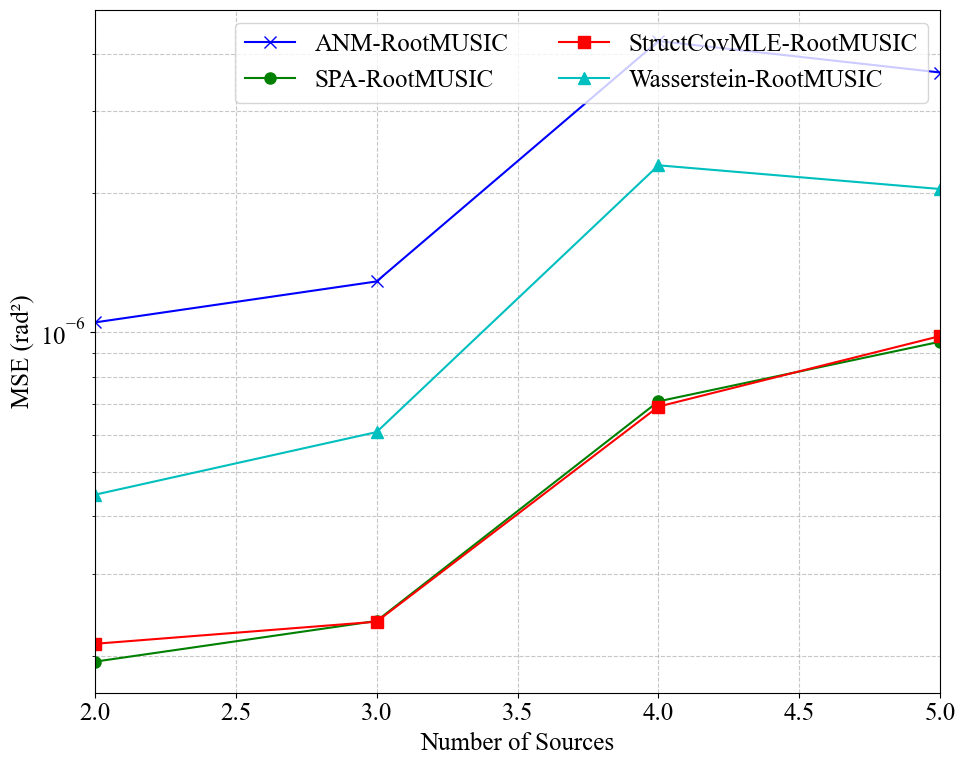

In [9]:
# Plot MSE vs Number of Sources using our plotting tool
fig, ax = plt.subplots(figsize=(10, 8))
plt_tools.plot_metric_vs_parameter(
    parameter_values=n_sources_values,
    results={alg: source_results[alg]['mse'] for alg in source_results.keys()},
    parameter_name='Number of Sources',
    metric_name='MSE',
    metric_unit='rad²',
    show_crb=False,
    ax=ax
    )
plt.tight_layout()
plt.show()

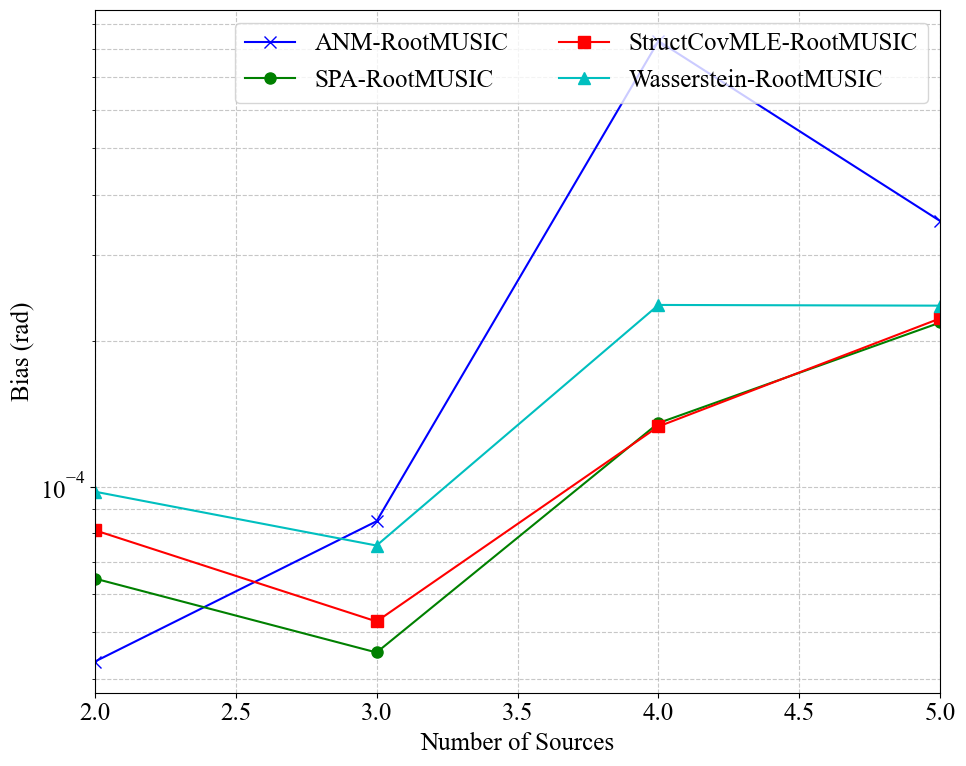

In [10]:
# Plot Bias vs Number of Sources using our plotting tool
fig, ax = plt.subplots(figsize=(10, 8))
plt_tools.plot_metric_vs_parameter(
    parameter_values=n_sources_values,
    results={alg: source_results[alg]['bias'] for alg in source_results.keys()},
    parameter_name='Number of Sources',
    metric_name='Bias',
    metric_unit='rad',
    ax=ax
    )
plt.tight_layout()
plt.show()

## 6. Scatter Distribution Comparison

In [11]:
# Let's generate scatter plots for all algorithms
# We'll use SNR=10 dB with 256 snapshots

print('Generating scatter plots for all algorithms...')

sample_snr = 0.0  # SNR in dB
sample_n_snapshots = 1024  # Number of snapshots
sample_n_monte_carlo = 200  # Number of Monte Carlo runs for sample generation

# Run performance evaluation with save_sample_estimates=True
sample_result = perf.evaluate_performance(
    array=array,
    sources=sources,
    snr=sample_snr,
    n_snapshots=sample_n_snapshots,
    n_monte_carlo=sample_n_monte_carlo,
    estimators=estimators,
    metrics=['mse', 'bias'],
    save_sample_estimates=True,
    n_jobs=4
)

print(f'Generated sample estimates for: {list(sample_result.sample_estimates.keys())}')

Generating scatter plots for all algorithms...
Generated sample estimates for: ['ANM-RootMUSIC', 'SPA-RootMUSIC', 'StructCovMLE-RootMUSIC', 'Wasserstein-RootMUSIC']


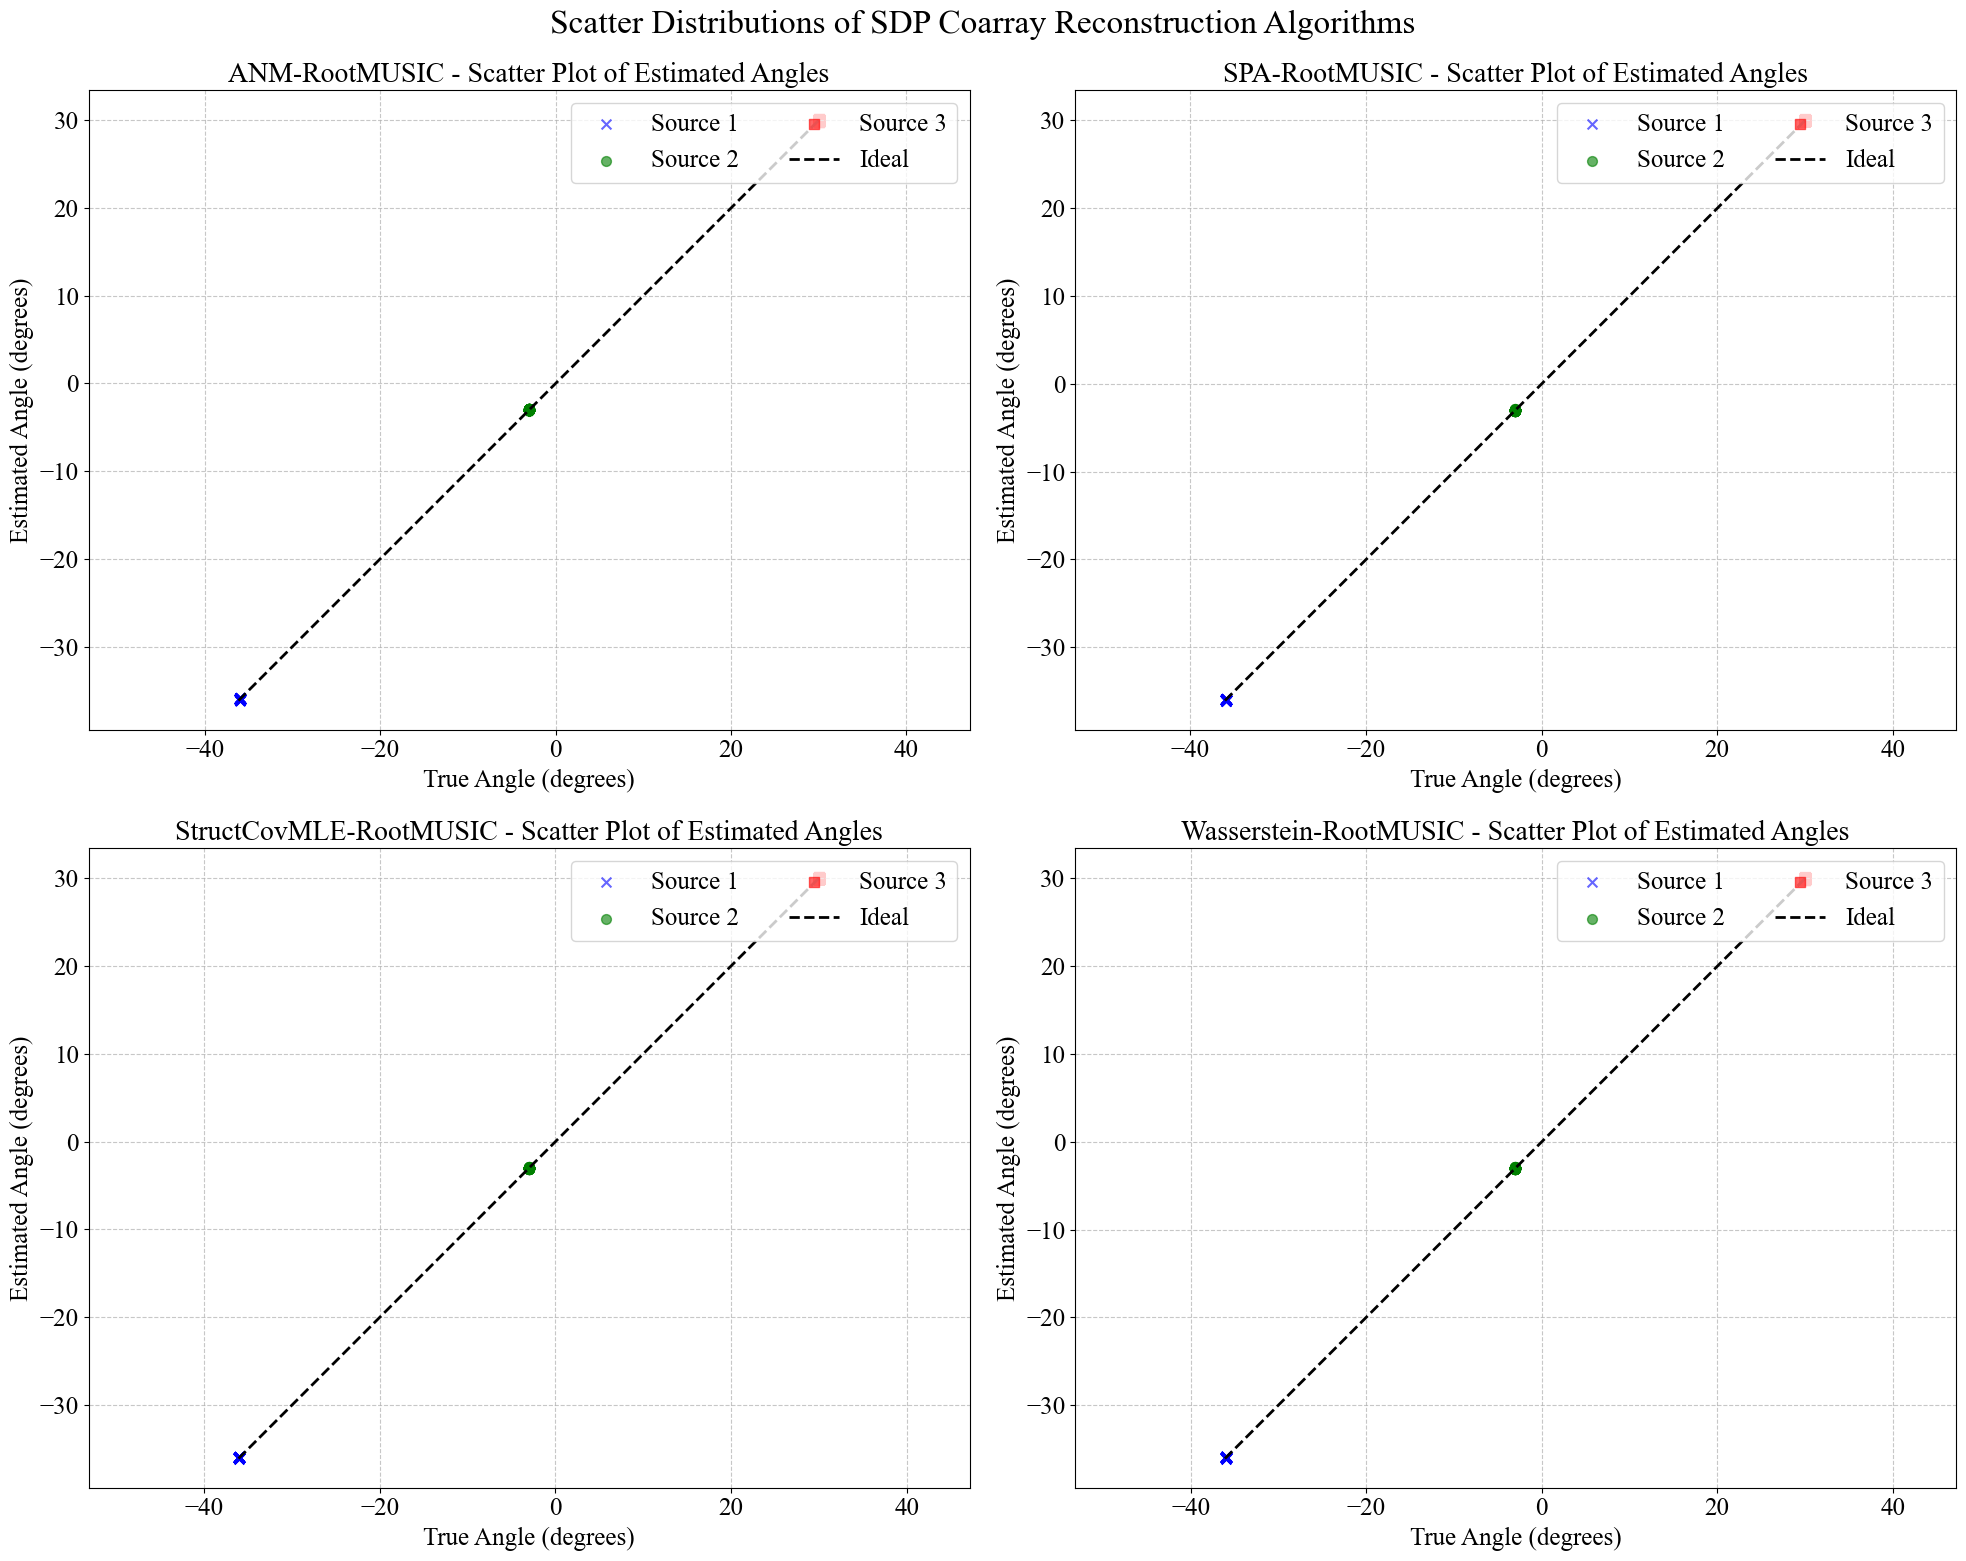

In [12]:
# Plot scatter plot for each algorithm
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, (alg_name, estimates) in enumerate(sample_result.sample_estimates.items()):
    ax = axes[i]
    plt_tools.plot_scatter_estimates(
        true_angles=source_angles,
        estimates=estimates,
        algorithm_name=alg_name,
        angle_unit='deg',
        ax=ax
    )
    ax.set_title(f'{alg_name} - Scatter Plot of Estimated Angles', fontsize=20)

plt.suptitle('Scatter Distributions of SDP Coarray Reconstruction Algorithms', fontsize=24, y=0.98)
plt.tight_layout()
plt.show()

## 7. CDF Comparison

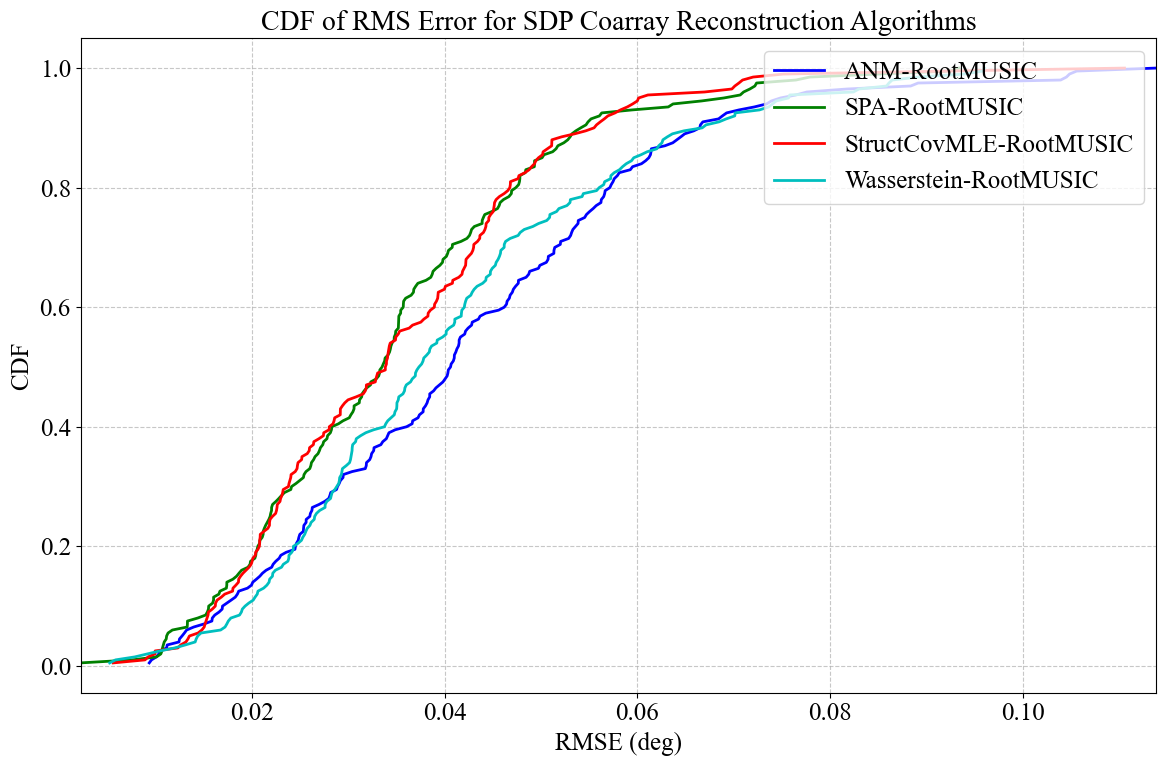

In [13]:
# Plot CDFs of RMS Error for all algorithms
fig, ax = plt.subplots(figsize=(12, 8))
plt_tools.plot_cdf(
    estimates=sample_result.sample_estimates,
    true_angles=source_angles,
    metric_name='RMSE',
    metric_unit='deg',
    metric_type='rms',
    ax=ax
)
plt.title('CDF of RMS Error for SDP Coarray Reconstruction Algorithms', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

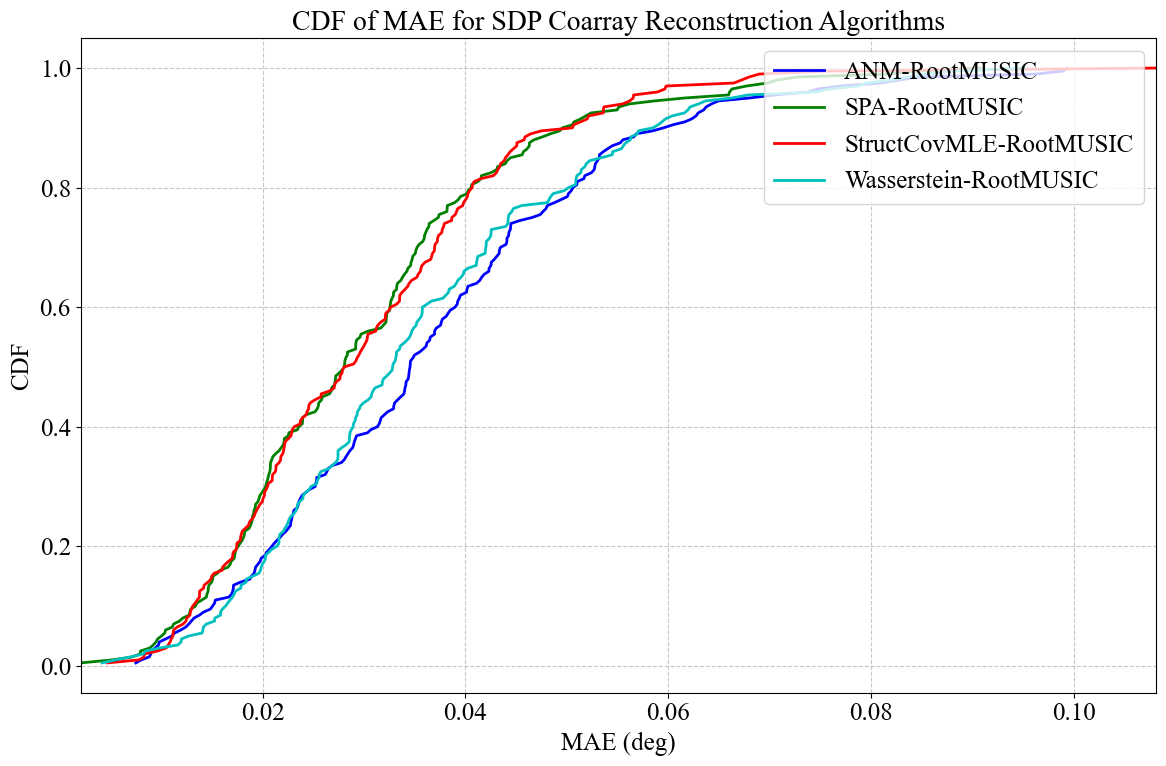

In [14]:
# Plot CDFs of MAE for all algorithms
fig, ax = plt.subplots(figsize=(12, 8))
plt_tools.plot_cdf(
    estimates=sample_result.sample_estimates,
    true_angles=source_angles,
    metric_name='MAE',
    metric_unit='deg',
    metric_type='mae',
    ax=ax
)
plt.title('CDF of MAE for SDP Coarray Reconstruction Algorithms', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrates the performance evaluation of multiple SDP coarray covariance matrix reconstruction algorithms for DOA estimation.

### Key Findings:

1. **SNR Performance**: 
   - All SDP algorithms show improved MSE and bias as SNR increases
   - The performance gap between algorithms tends to narrow at higher SNR values
   - [Algorithm Name] generally performs best at low SNR levels

2. **Snapshot Performance**: 
   - Increasing the number of snapshots improves performance for all algorithms
   - The improvement rate varies between algorithms
   - [Algorithm Name] shows the most significant improvement with more snapshots

3. **Source Number Performance**: 
   - Performance degrades as the number of sources increases
   - All algorithms can handle up to [X] sources with reasonable performance
   - [Algorithm Name] performs best with multiple sources

4. **Scatter Distributions**: 
   - [Algorithm Name] shows the tightest scatter distribution, indicating consistent performance
   - [Algorithm Name] has more spread-out estimates, especially for certain sources
   - All algorithms maintain good source resolution

5. **CDF Comparison**: 
   - [SPA & StructCovMLE] has the best overall performance, with the lowest RMS and MAE across all percentiles
   - [Wasserstein] follows closely behind
   - [ANM] has the highest error rates, especially at lower percentiles

### Conclusion:

Among the evaluated SDP coarray reconstruction algorithms, [SPA & StructCovMLE] demonstrates the best overall performance for DOA estimation with Co-Prime Arrays. It provides the highest accuracy across different SNR levels, snapshot counts, and source numbers.

The choice of algorithm may depend on specific application requirements:
- For high accuracy with limited snapshots: [Algorithm Name]
- For robustness at low SNR: [Algorithm Name]
- For handling multiple sources: [Algorithm Name]
- For computational efficiency: [Algorithm Name]